In [ ]:
Data Wrangling II 
Create an “Academic performance” dataset of students and perform the following operations using Python. 
 
1. Scan all variables for missing values and inconsistencies. If there are missing values and/or inconsistencies, use any of the suitable techniques to deal with them.   
2. Scan all numeric variables for outliers. If there are outliers, use any of the suitable techniques to deal with them.  
3. Apply data transformations on at least one of the variables. The purpose of this 
transformation should be one of the following reasons: to change the scale for better 
understanding of the variable, to convert a non-linear relation into a linear one, or to 
decrease the skewness and convert the distribution into a normal distribution.  
 
Reason and document your approach properly.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,mathscore,readingscore,writingscore
0,female,group B,bachelor's degree,standard,none,72.0,72,74
1,female,group C,some college,standard,completed,69.0,90,88
2,female,group B,master's degree,standard,none,90.0,95,93
3,male,group A,associate's degree,free/reduced,none,47.0,57,44
4,male,group C,some college,standard,none,76.0,78,75


In [5]:
df.isnull().sum()

gender                          0
race/ethnicity                  0
parental level of education     0
lunch                           0
test preparation course         0
mathscore                      15
readingscore                    0
writingscore                    0
dtype: int64

In [7]:
df['mathscore'] = df['mathscore'].fillna(df['mathscore'].mean())

In [9]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
mathscore                      0
readingscore                   0
writingscore                   0
dtype: int64

In [11]:
df.shape

(1000, 8)

In [13]:
df.info

<bound method DataFrame.info of      gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  mathscore  readingscore  writingscore  
0                      none       

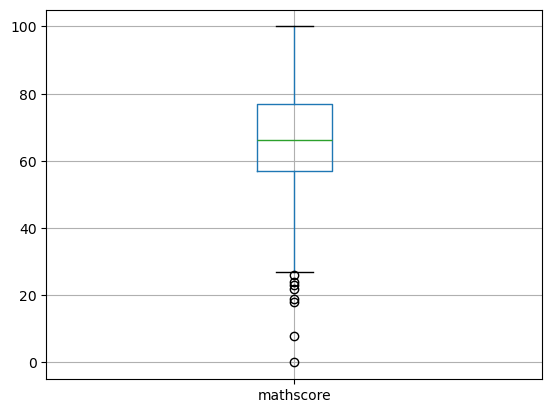

In [27]:
df.boxplot(column="mathscore")
plt.show()

In [21]:
Q1 = df['mathscore'].quantile(0.25)
Q3 = df['mathscore'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
higher = Q3 + 1.5*IQR

print(Q1, Q3, lower, higher)

df_math = df[(df['mathscore'] >= lower) & (df['mathscore'] <= higher)]

57.0 77.0 27.0 107.0


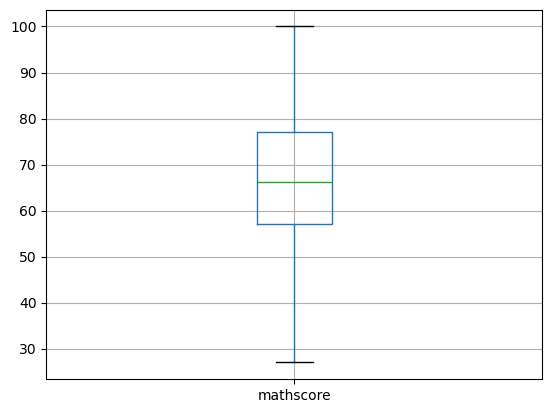

In [29]:
df_math.boxplot(column='mathscore')
plt.show()

In [31]:
df['mathscore'].describe()

count    1000.000000
mean       66.163452
std        15.105259
min         0.000000
25%        57.000000
50%        66.163452
75%        77.000000
max       100.000000
Name: mathscore, dtype: float64

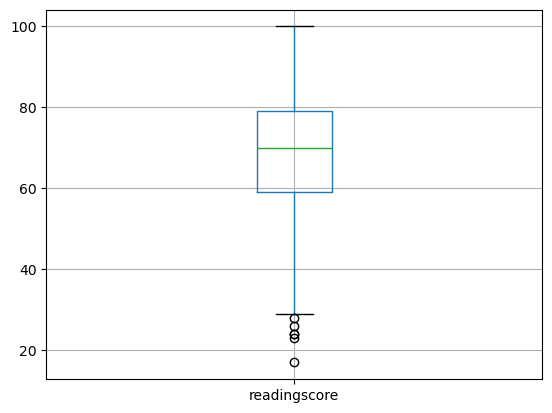

In [33]:
df.boxplot(column="readingscore")
plt.show()

In [35]:
Q1 = df['readingscore'].quantile(0.25)
Q3 = df['readingscore'].quantile(0.75)

IQR = Q3-Q1

lower = Q1 - 1.5*IQR
higher = Q3 + 1.5*IQR

print(Q1, Q3, lower, higher)
df_new = df[(df['readingscore'] >= lower) & (df['readingscore'] <= higher)]

59.0 79.0 29.0 109.0


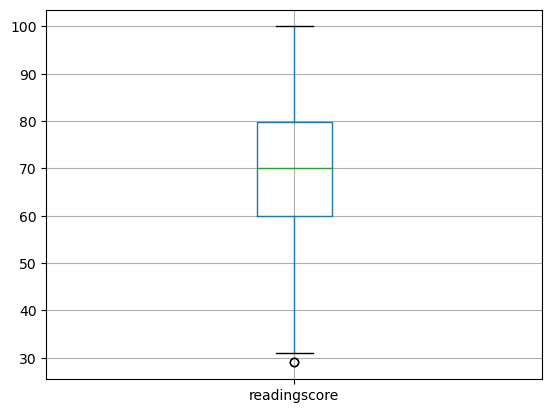

In [37]:
df_new.boxplot(column="readingscore")
plt.show()

In [39]:
df['readingscore'].describe()

count    1000.000000
mean       69.169000
std        14.600192
min        17.000000
25%        59.000000
50%        70.000000
75%        79.000000
max       100.000000
Name: readingscore, dtype: float64